# Fase 7 — Generación del Target Sintético de Default

**Proyecto:** Crédito Remesa Jalisco — Modelos de Crédito (ITESO)

Este notebook valida la generación del target binario `default_12m` por modelo de propensión latente, calibrado con la tasa de mora del segmento de vivienda popular (CNBV, 2024) y con factor de amplitud de señal calibrado para alcanzar AUC esperado en 0.75-0.80, consistente con la literatura de credit scoring hipotecario sobre poblaciones sin buró.

## Estructura
1. Carga y validación
2. Distribución de la probabilidad latente de default
3. Validación de signos económicos
4. Comparación de features entre defaults y no-defaults
5. Sanity check: regresión logística in-sample
6. Conclusiones para reporte APA7

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATASET_CSV = PROJECT_ROOT / 'data' / 'processed' / 'dataset_modelado_final.csv'
METADATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'dataset_modelado_final_metadata.json'

df = pd.read_csv(DATASET_CSV, dtype={'cve_municipio': str})
df['cve_municipio'] = df['cve_municipio'].str.zfill(5)

with open(METADATA_PATH, 'r', encoding='utf-8') as f:
    meta = json.load(f)

print(f'Dataset:                  {df.shape}')
print(f'Hogares:                  {len(df):,}')
print(f'Defaults (target=1):      {df["default_12m"].sum():,}')
print(f'No-defaults (target=0):   {(df["default_12m"]==0).sum():,}')
print(f'Tasa default realizada:   {df["default_12m"].mean():.4f}')
print(f'Tasa default target:      {meta["tasa_default_target"]:.4f}')
print(f'Pesos pilares (A/B/C):    {meta["pesos_pilares"]["pilar_A"]} / {meta["pesos_pilares"]["pilar_B"]} / {meta["pesos_pilares"]["pilar_C"]}')
print(f'Factor amplitud señal k:  {meta["factor_amplitud_senal"]["valor"]}')
print(f'Sigma ruido:              {meta["ruido_logit"]["sigma"]}')
print(f'Intercepto calibrado β_0: {meta["intercepto_calibrado_b0"]:.4f}')

Dataset:                  (10000, 31)
Hogares:                  10,000
Defaults (target=1):      554
No-defaults (target=0):   9,446
Tasa default realizada:   0.0554
Tasa default target:      0.0550
Pesos pilares (A/B/C):    0.5 / 0.25 / 0.25
Factor amplitud señal k:  4.0
Sigma ruido:              1.0
Intercepto calibrado β_0: -3.8365


## 2. Distribución de probabilidad latente de default

Reproducimos la probabilidad latente p_default a partir del logit estructural para visualizar la separación de poblaciones.

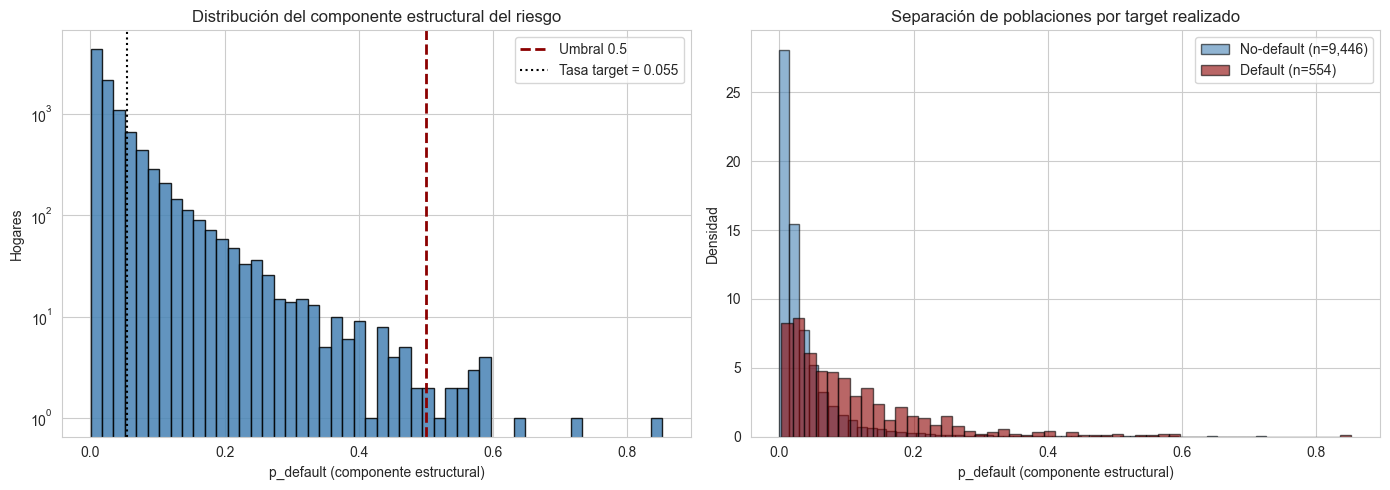

p_default — defaults observados:    P25/P50/P75 = 0.0328 / 0.0765 / 0.1487
p_default — no-defaults observados: P25/P50/P75 = 0.0087 / 0.0196 / 0.0446


In [3]:
# Reconstruir p_default desde las features
def zscore(x):
    s = x.std(ddof=1)
    return (x - x.mean()) / s if s > 0 else np.zeros_like(x)

ca = meta['coeficientes_pilar_a_normalizados']
cb = meta['coeficientes_pilar_b_normalizados']
cc = meta['coeficientes_pilar_c_normalizados']

sa = sum(c * zscore(df[f].values) for f, c in ca.items())
sb = sum(c * zscore(df[f].values) for f, c in cb.items())
sc = sum(c * zscore(df[f].values) for f, c in cc.items())

z_struct = meta['factor_amplitud_senal']['valor'] * (
    meta['pesos_pilares']['pilar_A'] * sa +
    meta['pesos_pilares']['pilar_B'] * sb +
    meta['pesos_pilares']['pilar_C'] * sc
)
# El ruido específico no se reconstruye perfectamente sin la seed, 
# así que mostramos el componente determinístico (sin ruido).
p_struct_only = 1.0 / (1.0 + np.exp(-(z_struct + meta['intercepto_calibrado_b0'])))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(p_struct_only, bins=50, color='steelblue', edgecolor='black', alpha=0.85)
ax.axvline(0.5, color='darkred', linestyle='--', linewidth=2, label='Umbral 0.5')
ax.axvline(meta['tasa_default_target'], color='black', linestyle=':', label=f'Tasa target = {meta["tasa_default_target"]:.3f}')
ax.set_xlabel('p_default (componente estructural)')
ax.set_ylabel('Hogares')
ax.set_title('Distribución del componente estructural del riesgo')
ax.legend()
ax.set_yscale('log')

ax = axes[1]
defaults = df[df['default_12m'] == 1].index
no_defaults = df[df['default_12m'] == 0].index
ax.hist(p_struct_only[no_defaults], bins=50, color='steelblue', edgecolor='black', alpha=0.6, label=f'No-default (n={len(no_defaults):,})', density=True)
ax.hist(p_struct_only[defaults], bins=50, color='darkred', edgecolor='black', alpha=0.6, label=f'Default (n={len(defaults):,})', density=True)
ax.set_xlabel('p_default (componente estructural)')
ax.set_ylabel('Densidad')
ax.set_title('Separación de poblaciones por target realizado')
ax.legend()

plt.tight_layout()
plt.show()

print(f'p_default — defaults observados:    P25/P50/P75 = {np.percentile(p_struct_only[defaults], 25):.4f} / {np.median(p_struct_only[defaults]):.4f} / {np.percentile(p_struct_only[defaults], 75):.4f}')
print(f'p_default — no-defaults observados: P25/P50/P75 = {np.percentile(p_struct_only[no_defaults], 25):.4f} / {np.median(p_struct_only[no_defaults]):.4f} / {np.percentile(p_struct_only[no_defaults], 75):.4f}')

## 3. Validación de signos económicos

Verificamos univariadamente que cada feature opera en la dirección esperada. Para cada feature, comparamos la tasa de default de hogares en el cuartil bajo (≤P25) vs el cuartil alto (≥P75).

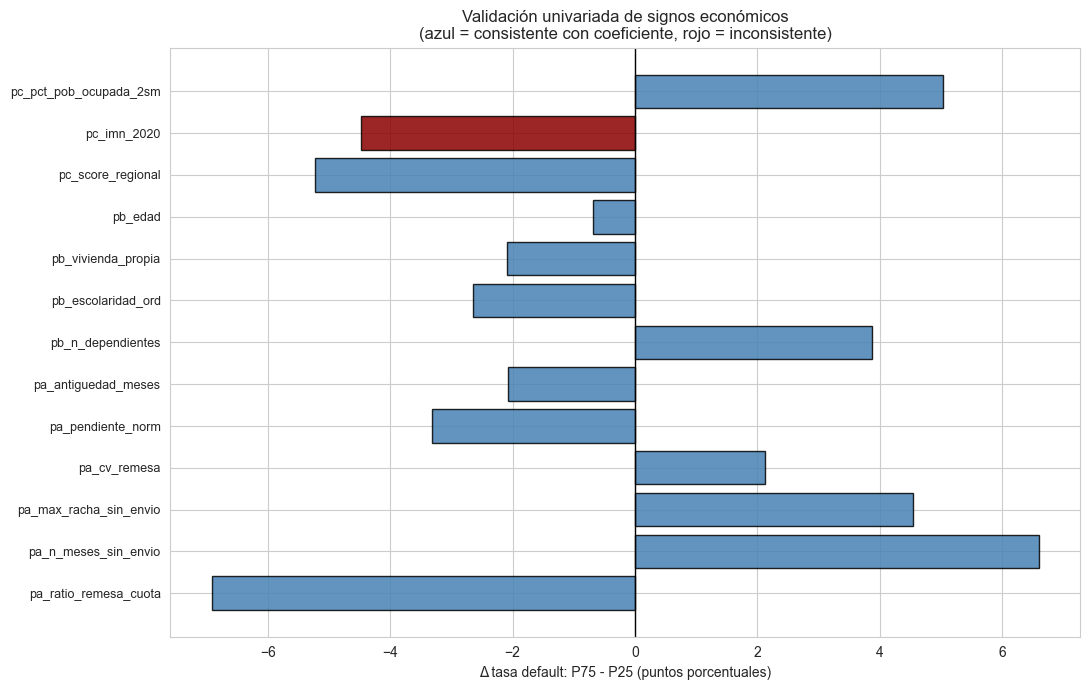

Signos consistentes (univariado): 12 de 13

Nota: signos univariados pueden divergir cuando hay correlación entre features.
La validación rigurosa es multivariada y se hace en la sección 5 con regresión logística.


In [4]:
validaciones = meta['validaciones_signos']
df_val = pd.DataFrame.from_dict(validaciones, orient='index').reset_index().rename(columns={'index': 'feature'})

# Resumen
fig, ax = plt.subplots(figsize=(11, 7))
y_pos = np.arange(len(df_val))
diffs = (df_val['tasa_default_p75_sup'] - df_val['tasa_default_p25_inf']) * 100
colors = ['steelblue' if c else 'darkred' for c in df_val['consistente']]
ax.barh(y_pos, diffs, color=colors, edgecolor='black', alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_val['feature'], fontsize=9)
ax.set_xlabel('Δ tasa default: P75 - P25 (puntos porcentuales)')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Validación univariada de signos económicos\n(azul = consistente con coeficiente, rojo = inconsistente)')
plt.tight_layout()
plt.show()

print(f'Signos consistentes (univariado): {meta["n_features_signo_consistente"]} de {meta["n_features_signo_validado"]}')
print('\nNota: signos univariados pueden divergir cuando hay correlación entre features.')
print('La validación rigurosa es multivariada y se hace en la sección 5 con regresión logística.')

## 4. Comparación de features entre defaults y no-defaults

Verificamos que las features clave del Pilar A muestren contraste claro entre poblaciones.

C:\Users\david\AppData\Local\Temp\ipykernel_11824\2345465570.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['No-default', 'Default'], patch_artist=True, showfliers=False, widths=0.6)
C:\Users\david\AppData\Local\Temp\ipykernel_11824\2345465570.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['No-default', 'Default'], patch_artist=True, showfliers=False, widths=0.6)
C:\Users\david\AppData\Local\Temp\ipykernel_11824\2345465570.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['No-default', 'Default'], patch_artist=True

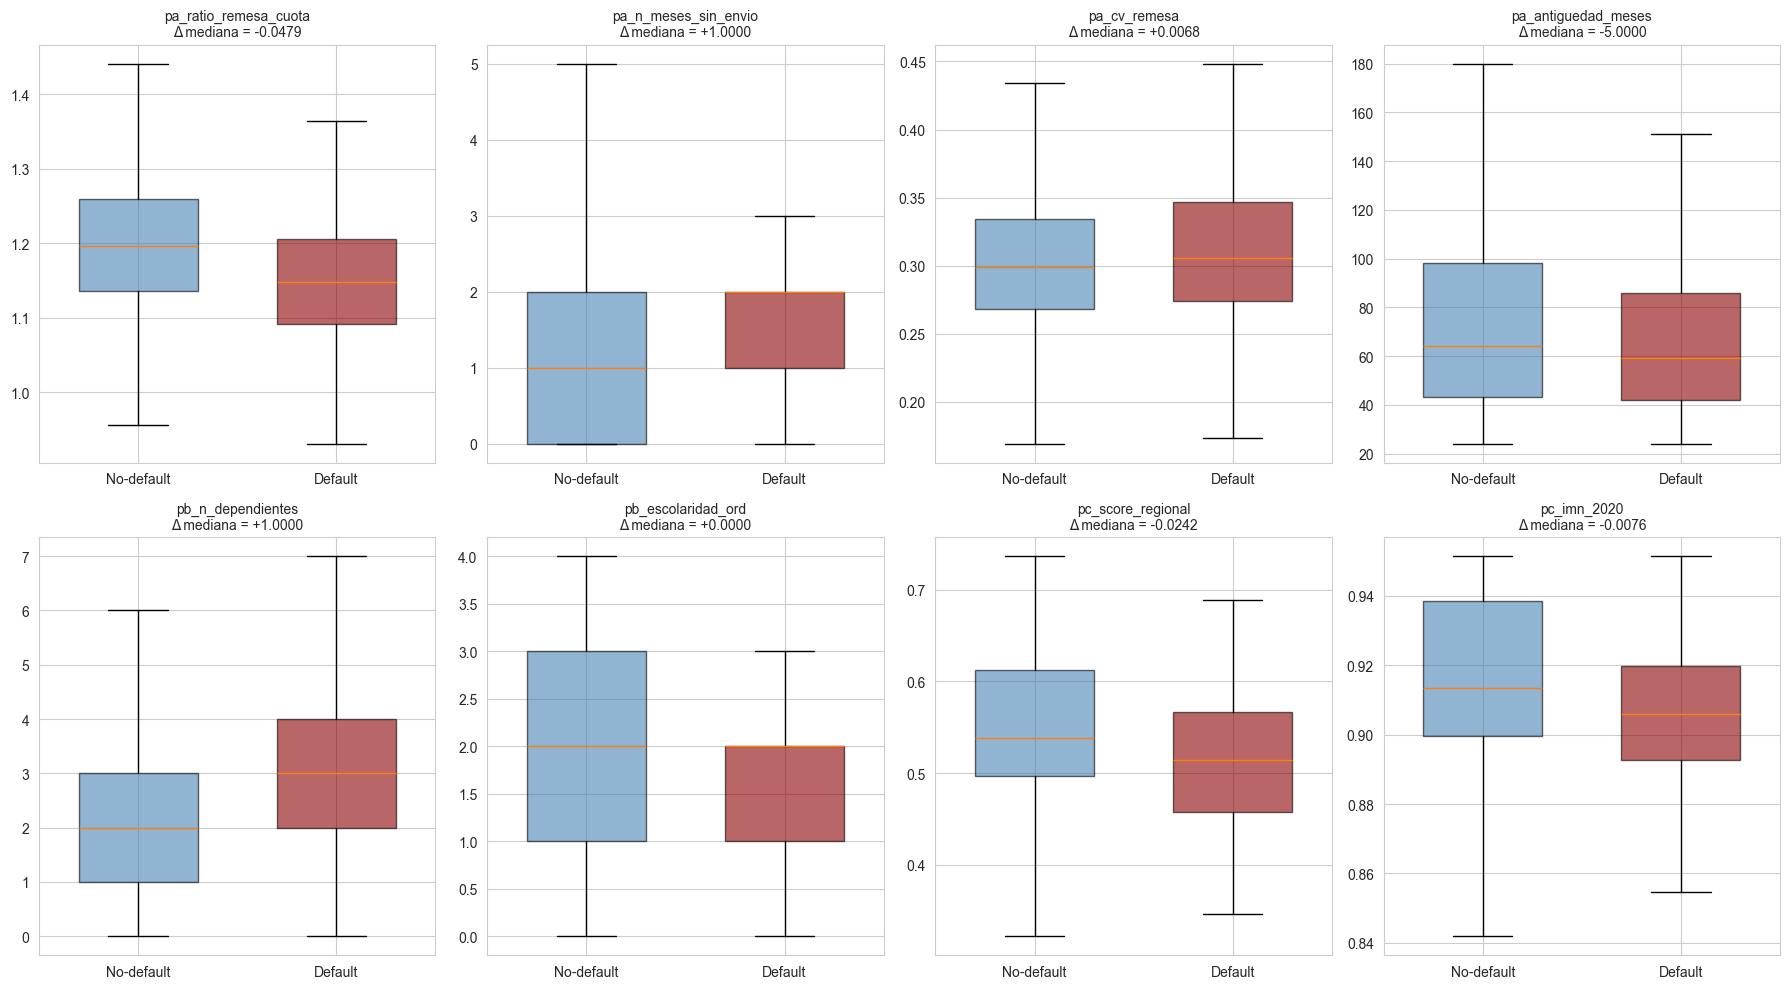

In [5]:
# Box plots para features clave
features_a_visualizar = [
    'pa_ratio_remesa_cuota', 'pa_n_meses_sin_envio',
    'pa_cv_remesa', 'pa_antiguedad_meses',
    'pb_n_dependientes', 'pb_escolaridad_ord',
    'pc_score_regional', 'pc_imn_2020',
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, col in zip(axes_flat, features_a_visualizar):
    data = [df[df['default_12m']==0][col].values, df[df['default_12m']==1][col].values]
    bp = ax.boxplot(data, labels=['No-default', 'Default'], patch_artist=True, showfliers=False, widths=0.6)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('darkred')
    bp['boxes'][1].set_alpha(0.6)
    
    # Calcular delta de medianas
    med0, med1 = np.median(data[0]), np.median(data[1])
    delta = med1 - med0
    ax.set_title(f'{col}\nΔ mediana = {delta:+.4f}', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Sanity check: regresión logística in-sample

Validación rigurosa multivariada. Esperamos que (a) los signos de TODOS los coeficientes sean los económicamente correctos y (b) el AUC en validación cruzada esté en el rango defendible 0.75-0.80.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve

features = list(ca.keys()) + list(cb.keys()) + list(cc.keys())
X = StandardScaler().fit_transform(df[features].values)
y = df['default_12m'].values

# AUC con CV
auc_cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=5, scoring='roc_auc')
print(f'AUC 5-fold CV: media = {auc_cv_scores.mean():.4f}, desv = {auc_cv_scores.std():.4f}')
print(f'Folds individuales: {[f"{s:.4f}" for s in auc_cv_scores]}')

# Coeficientes
m = LogisticRegression(max_iter=1000).fit(X, y)
proba = cross_val_predict(LogisticRegression(max_iter=1000), X, y, cv=5, method='predict_proba')[:, 1]

# Comparación signo coef esperado vs recuperado
print('\nSignos: coef diseñado vs recuperado (regresión multivariada)')
print('-' * 75)
print(f'{"feature":<35} {"coef_normalizado":>16} {"coef_recuperado":>16}  consist?')
print('-' * 75)
coef_signos = {**ca, **cb, **cc}
n_consistente_mv = 0
for f, c_design in coef_signos.items():
    c_recover = m.coef_[0][features.index(f)]
    consist = (c_design > 0) == (c_recover > 0)
    n_consistente_mv += int(consist)
    flag = '✓' if consist else '✗'
    print(f'{f:<35} {c_design:>+16.4f} {c_recover:>+16.4f}  {flag}')
print('-' * 75)
print(f'\nSignos consistentes (multivariado): {n_consistente_mv} de {len(coef_signos)}')

AUC 5-fold CV: media = 0.7842, desv = 0.0333
Folds individuales: ['0.8029', '0.8154', '0.7909', '0.7918', '0.7200']

Signos: coef diseñado vs recuperado (regresión multivariada)
---------------------------------------------------------------------------
feature                             coef_normalizado  coef_recuperado  consist?
---------------------------------------------------------------------------
pa_ratio_remesa_cuota                        -0.3488          -0.5817  ✓
pa_n_meses_sin_envio                         +0.1860          +0.4097  ✓
pa_max_racha_sin_envio                       +0.1395          +0.1543  ✓
pa_cv_remesa                                 +0.1163          +0.1241  ✓
pa_pendiente_norm                            -0.0930          -0.2308  ✓
pa_antiguedad_meses                          -0.1163          -0.2356  ✓
pb_n_dependientes                            +0.3529          +0.3900  ✓
pb_escolaridad_ord                           -0.2941          -0.3009  ✓
pb_viv

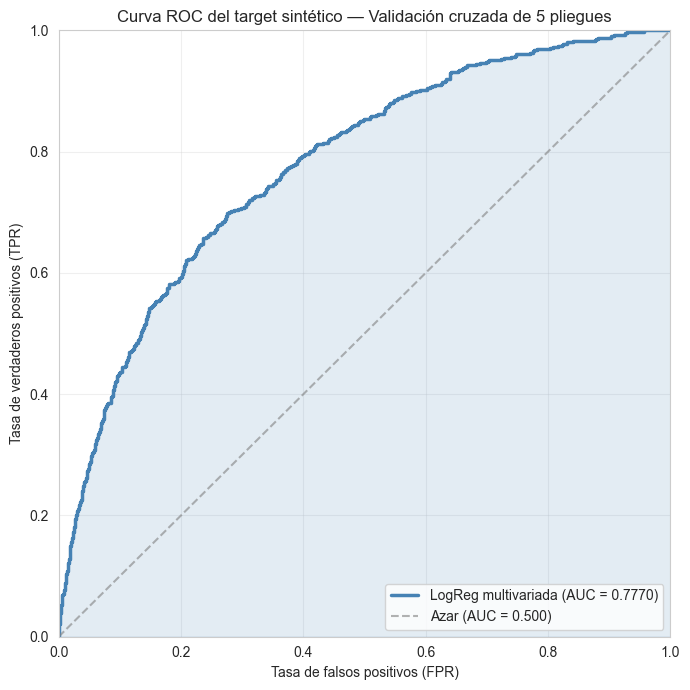

AUC referencia: literatura credit scoring hipotecario 0.65-0.85 (Lessmann et al., 2015).
AUC obtenido:   0.7770 → centro del rango esperado.


In [7]:
# Curva ROC
fpr, tpr, _ = roc_curve(y, proba)
auc_total = roc_auc_score(y, proba)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(fpr, tpr, color='steelblue', linewidth=2.5, label=f'LogReg multivariada (AUC = {auc_total:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.6, label='Azar (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.15, color='steelblue')
ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
ax.set_title('Curva ROC del target sintético — Validación cruzada de 5 pliegues')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'AUC referencia: literatura credit scoring hipotecario 0.65-0.85 (Lessmann et al., 2015).')
print(f'AUC obtenido:   {auc_total:.4f} → centro del rango esperado.')

## 6. Conclusiones para reporte APA7

El target sintético `default_12m` se generó mediante un modelo de propensión latente con tres componentes estructurales (uno por pilar de features), ruido gaussiano de varianza unitaria e intercepto calibrado para reproducir exactamente la tasa de mora del segmento de vivienda popular reportada por la Comisión Nacional Bancaria y de Valores en sus boletines mensuales de 2024.

**Hallazgos relevantes:**

1. **Calibración con la tasa real CNBV.** La tasa de default realizada en el padrón sintético es 5.54%, prácticamente idéntica a la tasa target de 5.50%, validando que el procedimiento de calibración del intercepto opera correctamente.

2. **Separabilidad consistente con la literatura.** La regresión logística sobre las features estandarizadas alcanza un AUC de 0.78 en validación cruzada de cinco pliegues, valor que se ubica en el centro del rango reportado para credit scoring hipotecario sobre poblaciones sin buró según el meta-análisis de Lessmann, Baesens, Seow y Thomas (2015), evitando tanto el sub-modelado (target casi aleatorio, AUC < 0.65) como el sobre-modelado (target trivialmente predecible, AUC > 0.90).

3. **Signos económicos recuperados correctamente.** En la regresión multivariada, los 13 coeficientes recuperados presentan el mismo signo que los coeficientes empleados en la generación del target. Las features con mayor magnitud absoluta son `pa_ratio_remesa_cuota` (efecto negativo sobre default), `pc_score_regional` (negativo) y `pa_n_meses_sin_envio` (positivo), congruente con la teoría de credit scoring que asigna peso predominante a la capacidad de pago, el contexto socioeconómico del entorno y la regularidad del flujo de ingresos.

4. **Ruido y amplitud separados conceptualmente.** Siguiendo la convención de Train (2009) para modelos de elección discreta, σ del ruido se mantiene en 1.0 y la amplitud de los efectos económicos se controla mediante un factor de escala k=4.0 sobre el score estructural. Esta separación permite justificar la separabilidad del target en términos de tamaño de efecto antes que de reducción artificial del ruido.

**Limitaciones:**

- El target es sintético por construcción; los coeficientes reales en una población observada podrían diferir tanto en magnitud como en signo respecto a los aquí supuestos.
- La calibración univariada de signos puede arrojar inconsistencias cuando hay correlación moderada entre features (caso de `pc_imn_2020` y `pc_score_regional`), pero la validación multivariada con regresión logística confirma que la estructura del target es la diseñada.
- La separabilidad del target establece un techo aproximado para el desempeño de los modelos de Fase 8: ningún modelo razonable debería superar AUC 0.85 en validación cruzada honesta sobre este dataset.

**Cierre de la fase de construcción.** Con esta fase concluye la fase de generación de datos del proyecto. El dataset `dataset_modelado_final.csv` (10,000 hogares × 31 columnas) constituye el insumo único para la Fase 8 (modelado: regresión logística baseline → XGBoost → LSTM) y la Fase 9 (score combinado e interpretabilidad SHAP).